# LSTM sobre fusão temporal (local + GPS + EKF2)

**Pré-requisito lógico:** `Infos_fusao_gps_local_ekf.ipynb` (merge `vehicle_local_position` + `vehicle_gps_position` + `ekf2_innovations`).

**Objetivo:** classificar o **cenário experimental** (`Normal` / `GPS Spoofing` / `Ping DoS`) a partir de **janelas multivariadas** de sensores alinhados.

**Split:** 80% / 20% **temporal dentro de cada voo** (sem misturar início e fim do mesmo log), depois concatenação dos conjuntos — reduz vazamento “vizinho a vizinho” dentro do mesmo ficheiro em relação a um split puramente aleatório.


## Síntese do que os dados mostram (antes do modelo)

Com base no `merge_asof` e nas séries já vistas nos notebooks anteriores:

| Sinal | Normal vs Ping DoS vs Spoofing |
|-------|----------------------------------|
| **Cadência `dt`** | ~**0,10 s** em todos — reflete o logger/SITL, **não** discrimina ataque. |
| **`dv_xy`** (módulo de **v_xy_loc − v_xy_gps**) | **Medianas ~0,037–0,038 m/s** muito parecidas; **máximos** ~0,77–0,88 m/s — pouco para separar **três classes** sozinho. |
| **`innov_norm` (‖vel_pos_innov[0:2]‖)** | **Medianas ~0,067** em todos; cauda global (`>p95`) ~**5%** em cada classe — **não** é um “alarme” trivial por limiar fixo. |
| **`eph_loc` / `eph_gps`** | Distribuições **muito sobrepostas** entre classes neste export. |
| **`r_xy`** (distância horizontal ao primeiro ponto do voo) | **Máximo ~3×10² m** (Normal / DoS) vs **~7,9×10⁴ m** (Spoofing) — **principal separador** do spoofing em relação aos outros dois. |

**Conclusão para o TCC:** o classificador precisa de **features que capturem trajetória** (`x`, `y`, acumulado ou `r_xy`) e, secundariamente, **inovações / discrepâncias**; esperar **confusão Normal ↔ Ping DoS** se o modelo depender sobretudo de ritmo ou de `eph`. O notebook abaixo inclui **`x`, `y`, `z`** e **`r_xy`** nas *features* por janela para refletir isso.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

def find_px4_quad_sitl() -> Path:
    'Sobe a partir do cwd até achar PX4-QUAD-SITL.'
    here = Path.cwd().resolve()
    for anchor in [here, *here.parents]:
        p = anchor / "data" / "UAVAttackData" / "Simulated - OTU Survey" / "PX4-QUAD-SITL"
        if p.is_dir():
            return p
    raise FileNotFoundError("data/UAVAttackData/.../PX4-QUAD-SITL")


BASE_PATH = find_px4_quad_sitl()
NORMAL, SPOOFING, DOS = BASE_PATH / "Normal", BASE_PATH / "GPS Spoofing", BASE_PATH / "Ping DoS"

LABEL_MAP = {"Normal": 0, "GPS Spoofing": 1, "Ping DoS": 2}


def pick_vehicle_local_position_csv(folder: Path) -> Path:
    matches = sorted(folder.glob("*vehicle_local_position*.csv"))
    matches = [m for m in matches if "setpoint" not in m.name and "groundtruth" not in m.name]
    if not matches:
        raise FileNotFoundError(folder)
    return matches[0]


def log_prefix(folder: Path) -> str:
    name = pick_vehicle_local_position_csv(folder).name
    suf = "_vehicle_local_position_0.csv"
    if not name.endswith(suf):
        raise ValueError(name)
    return name[: -len(suf)]


def load_merged(folder: Path, condition: str) -> pd.DataFrame:
    pref = log_prefix(folder)
    loc = pd.read_csv(folder / f"{pref}_vehicle_local_position_0.csv", sep=",").sort_values("timestamp")
    gps = pd.read_csv(folder / f"{pref}_vehicle_gps_position_0.csv", sep=",").sort_values("timestamp")
    ekf = pd.read_csv(folder / f"{pref}_ekf2_innovations_0.csv", sep=",").sort_values("timestamp")
    m = pd.merge_asof(loc, gps, on="timestamp", suffixes=("_loc", "_gps"), direction="backward")
    m = pd.merge_asof(m.sort_values("timestamp"), ekf.sort_values("timestamp"), on="timestamp", direction="backward")
    return m.assign(condition=condition)


merged = pd.concat(
    [
        load_merged(NORMAL, "Normal"),
        load_merged(SPOOFING, "GPS Spoofing"),
        load_merged(DOS, "Ping DoS"),
    ],
    ignore_index=True,
).copy()

cols_innov = ["vel_pos_innov[0]", "vel_pos_innov[1]", "vel_pos_innov[2]"]
M = merged[cols_innov].astype(float).to_numpy()
merged["innov_norm"] = np.sqrt(np.sum(M * M, axis=1))
merged["v_xy_gps"] = np.sqrt(merged["vel_n_m_s"].astype(float) ** 2 + merged["vel_e_m_s"].astype(float) ** 2)
merged["v_xy_loc"] = np.sqrt(merged["vx"].astype(float) ** 2 + merged["vy"].astype(float) ** 2)
merged["dv_xy"] = np.abs(merged["v_xy_loc"] - merged["v_xy_gps"])


def _r_xy_series(x, y):
    x0, y0 = float(x.iloc[0]), float(y.iloc[0])
    return np.sqrt((x - x0) ** 2 + (y - y0) ** 2)


merged["r_xy"] = 0.0
for _cond in merged["condition"].unique():
    _ix = merged["condition"] == _cond
    merged.loc[_ix, "r_xy"] = _r_xy_series(merged.loc[_ix, "x"], merged.loc[_ix, "y"]).to_numpy(dtype=float)
merged["y_label"] = merged["condition"].map(LABEL_MAP)

print(merged.shape)
merged.groupby("condition").size()


(44957, 113)


/var/folders/8_/_x4q463d1yl_x911vq7_v8kr0000gn/T/ipykernel_84336/2396537755.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  return m.assign(condition=condition)


condition
GPS Spoofing    15453
Normal          14765
Ping DoS        14739
dtype: int64

## 1. Features e hiperparâmetros

Lista fixa de colunas numéricas por passo de tempo; `WINDOW` e fração de treino ajustáveis.


In [2]:
FEATS = [
    "x",
    "y",
    "z",
    "vx",
    "vy",
    "vz",
    "eph_loc",
    "eph_gps",
    "innov_norm",
    "dv_xy",
    "r_xy",
]
WINDOW = 40
FRAC_TRAIN = 0.8

missing = [c for c in FEATS if c not in merged.columns]
if missing:
    raise ValueError("Colunas em falta: " + str(missing))

data = merged[FEATS + ["condition", "y_label", "timestamp"]].replace([np.inf, -np.inf], np.nan).dropna()
print("linhas após dropna:", len(data))


linhas após dropna: 44957


## 2. Janelas deslizantes + partição temporal por voo

Cada `condition` corresponde a **um** ficheiro de voo: o índice temporal ordenado define treino (primeiros 80%) e teste (últimos 20%).


In [3]:
def build_windows_for_condition(df: pd.DataFrame, window: int, frac_train: float):
    df = df.sort_values("timestamp").reset_index(drop=True)
    n = len(df)
    split = int(frac_train * n)
    split = max(split, window + 1)
    X_train, y_train = [], []
    X_test, y_test = [], []
    label = int(df["y_label"].iloc[0])
    for i in range(0, split - window):
        X_train.append(df.iloc[i : i + window][FEATS].to_numpy(dtype=np.float32))
        y_train.append(label)
    for i in range(split, n - window):
        X_test.append(df.iloc[i : i + window][FEATS].to_numpy(dtype=np.float32))
        y_test.append(label)
    return np.stack(X_train), np.array(y_train), np.stack(X_test), np.array(y_test)


X_tr_parts, y_tr_parts, X_te_parts, y_te_parts = [], [], [], []
for cond in ["Normal", "GPS Spoofing", "Ping DoS"]:
    sub = data.loc[data["condition"] == cond].copy()
    Xt, yt, Xe, ye = build_windows_for_condition(sub, WINDOW, FRAC_TRAIN)
    X_tr_parts.append(Xt)
    y_tr_parts.append(yt)
    X_te_parts.append(Xe)
    y_te_parts.append(ye)
    print(cond, "train windows", len(yt), "test windows", len(ye))

X_train = np.concatenate(X_tr_parts, axis=0)
y_train = np.concatenate(y_tr_parts)
X_test = np.concatenate(X_te_parts, axis=0)
y_test = np.concatenate(y_te_parts)
print("X_train", X_train.shape, "X_test", X_test.shape)


Normal train windows 11772 test windows 2913
GPS Spoofing train windows 12322 test windows 3051
Ping DoS train windows 11751 test windows 2908
X_train (35845, 40, 11) X_test (8872, 40, 11)


## 3. Normalização (só no treino)

`StandardScaler` ajustado aos passos do treino, aplicado igualmente a treino e teste.


In [4]:
from sklearn.preprocessing import StandardScaler

ns, win, nf = X_train.shape
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train.reshape(-1, nf)).reshape(ns, win, nf)
X_test_s = scaler.transform(X_test.reshape(-1, nf)).reshape(X_test.shape[0], win, nf)


## 4. LSTM (Keras) + validação temporal + *early stopping* + baseline RF

- Validação: últimos 10% do conjunto de treino concatenado (sem `validation_split` aleatório do Keras).
- `EarlyStopping` / `ModelCheckpoint` em `val_loss`.
- Matriz de confusão, curvas de aprendizado e **Random Forest** nas mesmas janelas achatadas (baseline).


Epoch 1/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7745 - loss: 0.4371 - val_accuracy: 0.2148 - val_loss: 3.1864
Epoch 2/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8601 - loss: 0.2642 - val_accuracy: 0.2706 - val_loss: 3.7676
Epoch 3/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8737 - loss: 0.2312 - val_accuracy: 0.2728 - val_loss: 3.8001
Epoch 4/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8832 - loss: 0.2132 - val_accuracy: 0.3319 - val_loss: 3.7239
Epoch 5/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8953 - loss: 0.1861 - val_accuracy: 0.3696 - val_loss: 3.8543
Epoch 6/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9024 - loss: 0.1788 - val_accuracy: 0.4061 - val_loss: 3.5944
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Épocas treinadas: 6


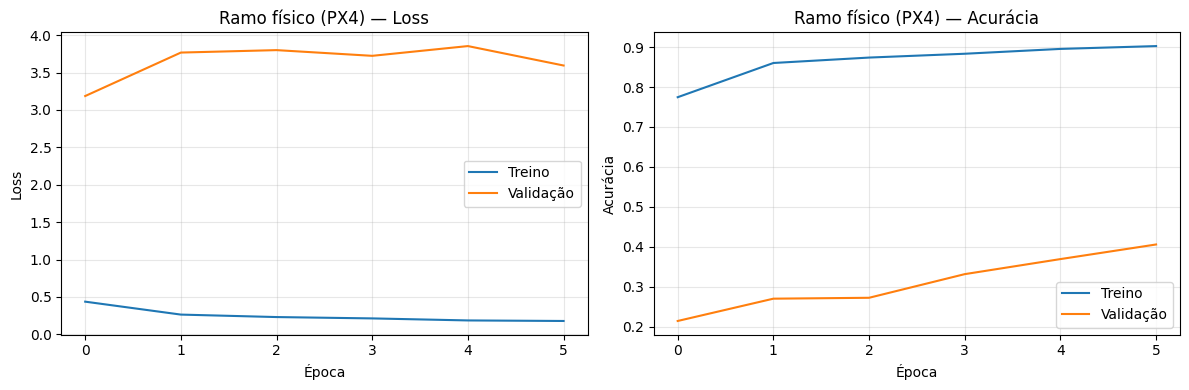

=== LSTM — Ramo físico (PX4) ===
              precision    recall  f1-score   support

      Normal      0.862     0.822     0.841      2913
GPS Spoofing      0.451     0.744     0.561      3051
    Ping DoS      0.461     0.166     0.245      2908

    accuracy                          0.580      8872
   macro avg      0.591     0.578     0.549      8872
weighted avg      0.589     0.580     0.549      8872

F1 macro (LSTM): 0.5491


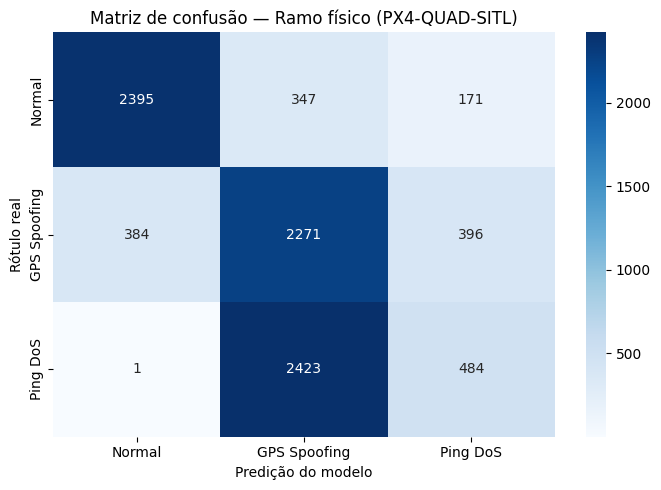

=== Random Forest — Ramo físico ===
              precision    recall  f1-score   support

      Normal      0.851     0.800     0.825      2913
GPS Spoofing      0.529     0.684     0.597      3051
    Ping DoS      0.699     0.526     0.600      2908

    accuracy                          0.671      8872
   macro avg      0.693     0.670     0.674      8872
weighted avg      0.691     0.671     0.673      8872

F1 macro (RF): 0.6741


In [5]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)

# A3 — validação temporal explícita (últimos 10% do treino), sem validation_split aleatório
val_split_idx = int(0.9 * len(X_train_s))
X_tr_fit, X_val_fit = X_train_s[:val_split_idx], X_train_s[val_split_idx:]
y_tr_fit, y_val_fit = y_train[:val_split_idx], y_train[val_split_idx:]

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)
checkpoint = ModelCheckpoint(
    "best_model_px4.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=0,
)

model = keras.Sequential(
    [
        layers.Input(shape=(WINDOW, nf)),
        layers.LSTM(48, return_sequences=False),
        layers.Dropout(0.25),
        layers.Dense(3, activation="softmax"),
    ]
)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(
    X_tr_fit,
    y_tr_fit,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_fit, y_val_fit),
    callbacks=[early_stop, checkpoint],
    verbose=1,
)
print(f"Épocas treinadas: {len(history.history['loss'])}")

# M3 — curvas de aprendizado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Treino")
axes[0].plot(history.history["val_loss"], label="Validação")
axes[0].set_title("Ramo físico (PX4) — Loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history["accuracy"], label="Treino")
axes[1].plot(history.history["val_accuracy"], label="Validação")
axes[1].set_title("Ramo físico (PX4) — Acurácia")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curves_ramo_fisico.png", dpi=150)
plt.show()

y_pred = np.argmax(model.predict(X_test_s, verbose=0), axis=1)
names = ["Normal", "GPS Spoofing", "Ping DoS"]
print("=== LSTM — Ramo físico (PX4) ===")
print(classification_report(y_test, y_pred, target_names=names, digits=3))
print(f"F1 macro (LSTM): {f1_score(y_test, y_pred, average='macro'):.4f}")

# A1 — matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names)
plt.xlabel("Predição do modelo")
plt.ylabel("Rótulo real")
plt.title("Matriz de confusão — Ramo físico (PX4-QUAD-SITL)")
plt.tight_layout()
plt.savefig("confusion_matrix_px4.png", dpi=150)
plt.show()

# A2 — baseline Random Forest (janelas achatadas)
X_train_flat = X_train_s.reshape(len(X_train_s), -1)
X_test_flat = X_test_s.reshape(len(X_test_s), -1)
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train)
y_pred_rf = rf.predict(X_test_flat)
print("=== Random Forest — Ramo físico ===")
print(classification_report(y_test, y_pred_rf, target_names=names, digits=3))
print(f"F1 macro (RF): {f1_score(y_test, y_pred_rf, average='macro'):.4f}")


In [6]:
# M4 (opcional) — repetir o treino LSTM com várias seeds e reportar F1 macro médio ± dp.
# Atenção: várias passagens completas de treino; deixe False por defeito.
RUN_MULTI_SEED = False

if RUN_MULTI_SEED:
    from sklearn.metrics import f1_score

    SEEDS = [42, 7, 13, 99, 2025]
    results = []
    for seed in SEEDS:
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed)
        np.random.seed(seed)
        m = keras.Sequential(
            [
                layers.Input(shape=(WINDOW, nf)),
                layers.LSTM(48, return_sequences=False),
                layers.Dropout(0.25),
                layers.Dense(3, activation='softmax'),
            ]
        )
        m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        m.fit(
            X_tr_fit,
            y_tr_fit,
            epochs=100,
            batch_size=64,
            validation_data=(X_val_fit, y_val_fit),
            callbacks=[
                EarlyStopping(
                    monitor='val_loss',
                    patience=5,
                    restore_best_weights=True,
                    verbose=0,
                )
            ],
            verbose=0,
        )
        yps = np.argmax(m.predict(X_test_s, verbose=0), axis=1)
        f1m = f1_score(y_test, yps, average='macro')
        results.append(f1m)
        print(f'Seed {seed}: F1 macro = {f1m:.4f}')
    print(f'\nF1 macro: {np.mean(results):.4f} ± {np.std(results):.4f}')

## 5. Limitações (para escrever no TCC)

- Só há **um voo por classe**; o split é **temporal dentro do mesmo ficheiro**, não “voo novo nunca visto”.
- **Normal** e **Ping DoS** podem ser **estatisticamente parecidos** em muitas features; o **spoofing** tende a destacar-se por **deriva horizontal** — a matriz de confusão e o baseline RF ajudam a quantificar confusões.
- A validação durante o treino usa o **final temporal** do bloco de treino concatenado; interpretar curvas `val_*` com esse contexto (mistura de classes por voo).
